In [1]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & SYNTHETIC MESSY DATASET GENERATOR
# Run this cell first to generate `raw_customer_orders.csv` and `dim_products.csv`.
# ==============================================================================
import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# 1. Primary Messy Dataset: raw_customer_orders.csv
messy_data = """Order_ID,Order_Date,Cust_ID,Customer_Name,Product_SKU,Units,Unit_Price,Shipping_City,Payment_Status
ORD-101,2024/01/15,C-1001,  Alice Smith ,SKU-E100,2,
45.50,los angeles,Completed
ORD-103,2024-01-18,C-1003,charlie brown,SKU-B300,-3,
250.00,HOUSTON,Completed
ORD-105,2024.01.22,C-1005,Emma Watson,SKU-H400,1,unknown,Miami,PENDING
ORD-106,2024-01-25,C-1006,Frank Castle,SKU-C200,2,
250.00,CHICAGO,Completed
ORD-108,2024-02-01,C-1008,Henry Ford,SKU-B300,10,
120.00,Miami,PENDING
ORD-110,2024-02-05,C-1010,Jack Ryan,SKU-E100,1,
250.00,HOUSTON,Completed
ORD-111,2024-02-10,C-1011,Karen Page,SKU-C200,1,
15.00,New York,Completed
ORD-113,2024-02-15,C-1013,Mona Lisa,SKU-E100,500,
120.00,Los Angeles,FAILED
ORD-115,2024-02-20,C-1015,Olivia Pope,SKU-C200,2,
15.00,New York,COMPLETED
ORD-117,2024-02-25,C-1017,Quinn Fabray,SKU-E100,1,
120.00,Miami,COMPLETED
ORD-119,2024-03-02,C-1019,Steve Rogers,SKU-C200,2,
250.00,New York,COMPLETED
"""

# 2. Secondary Dimension Table: dim_products.csv
dim_products = """Product_SKU,Category,Cost_Price,Supplier
SKU-E100,Electronics,180.00,Apex Tech
SKU-C200,Clothing,22.00,Global Fabrics
SKU-B300,Books,8.50,ReadWell Press
SKU-H400,Home & Kitchen,75.00,HomeCrafters
SKU-X900,Toys,12.00,ToyVerse
"""

with open("raw_customer_orders.csv", "w") as f:
    f.write(messy_data.strip())

with open("dim_products.csv", "w") as f:
    f.write(dim_products.strip())

print("✅ Files 'raw_customer_orders.csv' and 'dim_products.csv' generated successfully!")


✅ Files 'raw_customer_orders.csv' and 'dim_products.csv' generated successfully!


--- Missing Values Count per Column ---
Order_ID           0
Order_Date         0
Cust_ID            0
Customer_Name     10
Product_SKU       10
Units             10
Unit_Price        20
Shipping_City     20
Payment_Status    20
dtype: int64

--- Percentage of Missingness ---
Order_ID            0.0%
Order_Date          0.0%
Cust_ID             0.0%
Customer_Name     47.62%
Product_SKU       47.62%
Units             47.62%
Unit_Price        95.24%
Shipping_City     95.24%
Payment_Status    95.24%
dtype: object


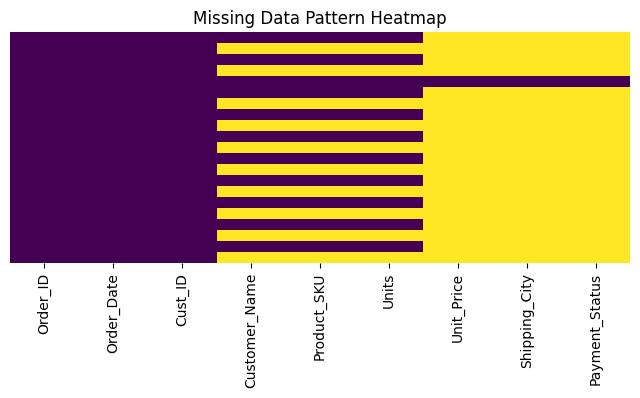

In [2]:
# ==============================================================================
# SECTION 1: MISSING DATA — DETECTION, VISUALISATION & IMPUTATION STRATEGIES
# ==============================================================================
df_demo = pd.read_csv("raw_customer_orders.csv")

# 1. Detection
print("--- Missing Values Count per Column ---")
print(df_demo.isna().sum())

print("\n--- Percentage of Missingness ---")
print((df_demo.isna().mean() * 100).round(2).astype(str) + "%")

# 2. Visualising Missingness via Heatmap
plt.figure(figsize=(8, 3))
sns.heatmap(df_demo.isna(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Data Pattern Heatmap")
plt.show()

# ------------------------------------------------------------------------------
# IMPUTATION STRATEGIES & STATISTICAL BIAS SUMMARY
# ------------------------------------------------------------------------------
# 1. dropna(axis=0/1, how='any'/'all', thresh=k)
#    - Appropriate: When missing completely at random (MCAR) and proportion < 3%.
#    - Bias: Reduces sample size, inflates variance, induces selection bias if MAR/MNAR.
# 2. fillna(constant) (e.g., 'Unknown', 0)
#    - Appropriate: Categorical variables where absence is informative.
#    - Bias: Creates artificial spikes at the constant value.
# 3. fillna(mean) vs fillna(median)
#    - Mean: Assumes normal distribution; artificially deflates standard deviation.
#    - Median: Robust to outliers; best for skewed numeric features.
# 4. ffill() / bfill() (Forward/Backward fill)
#    - Appropriate: Time-series / sequential sensor or financial ticker data.
#    - Bias: Propagates historical values; assumes stationarity between intervals.
# 5. interpolate(method='linear')
#    - Appropriate: Ordered numeric/time series with smooth continuous changes.

In [3]:
# ==============================================================================
# SECTION 2: DUPLICATES, TYPE CORRECTION, STRINGS & DATES
# ==============================================================================
toy_df = pd.DataFrame({
    'date_raw': ['2024-01-01', '02/01/2024', '2024.01.03', 'corrupted'],
    'price_raw': ['$100.50', '200.00', 'missing', '$350.75'],
    'name_raw': ['  JOHN Doe ', 'JANE DOE  ', 'Bob Smith', 'ALICE w. ']
})

# 1. Duplicate Handling
# subset: columns to check; keep: 'first', 'last', or False (drop all duplicates)
print("Duplicate rows check:", toy_df.duplicated().sum())

# 2. Data Type Correction & Robust Numeric Parsing
toy_df['price_clean'] = pd.to_numeric(
    toy_df['price_raw'].astype(str).str.replace('$', '', regex=False),
    errors='coerce'  # Converts unparseable strings ('missing') to NaN
)

# 3. Robust Datetime Parsing (Format Coercion)
toy_df['date_clean'] = pd.to_datetime(toy_df['date_raw'], errors='coerce', format='mixed')

# 4. String Cleaning via .str Accessor
toy_df['name_clean'] = toy_df['name_raw'].str.strip().str.title()
toy_df['first_name'] = toy_df['name_clean'].str.extract(r'^([A-Za-z]+)')

# 5. Date Component Extraction
toy_df['year'] = toy_df['date_clean'].dt.year
toy_df['month'] = toy_df['date_clean'].dt.month
toy_df['day_name'] = toy_df['date_clean'].dt.day_name()
toy_df['is_weekend'] = toy_df['date_clean'].dt.dayofweek.isin([5, 6])

display(toy_df)

Duplicate rows check: 0


,date_raw,price_raw,name_raw,price_clean,date_clean,name_clean,first_name,year,month,day_name,is_weekend
0,2024-01-01,$100.50,JOHN Doe,100.50,2024-01-01,John Doe,John,2024.0,1.0,Monday,False
1,02/01/2024,200.00,JANE DOE,200.00,2024-02-01,Jane Doe,Jane,2024.0,2.0,Thursday,False
2,2024.01.03,missing,Bob Smith,NaN,2024-01-03,Bob Smith,Bob,2024.0,1.0,Wednesday,False
3,corrupted,$350.75,ALICE w.,350.75,NaT,Alice W.,Alice,NaN,NaN,NaN,False


In [4]:
# ==============================================================================
# SECTION 3: OUTLIER DETECTION & TREATMENT (IQR & Z-SCORE)
# ==============================================================================
# Synthetic distribution with extreme outliers
vals = np.array([10, 12, 12, 13, 14, 15, 16, 18, 19, 20, 22, 150, -50])
outlier_df = pd.DataFrame({'value': vals})

# --- Method A: Interquartile Range (IQR) ---
# Robust against non-normal distributions
Q1 = outlier_df['value'].quantile(0.25)
Q3 = outlier_df['value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = outlier_df[(outlier_df['value'] < lower_bound) | (outlier_df['value'] > upper_bound)]
print(f"IQR Bounds: [{lower_bound:.2f}, {upper_bound:.2f}] | Outliers detected: {len(outliers_iqr)}")

# --- Method B: Z-Score ---
# Assumes approximately normal distribution (flag when |z| > 3)
mean_val = outlier_df['value'].mean()
std_val = outlier_df['value'].std()
outlier_df['z_score'] = (outlier_df['value'] - mean_val) / std_val
outliers_z = outlier_df[outlier_df['z_score'].abs() > 3]

# --- Treatment Strategies ---
# 1. Trimming (Dropping)
trimmed_df = outlier_df[(outlier_df['value'] >= lower_bound) & (outlier_df['value'] <= upper_bound)]

# 2. Winsorization / Capping (Clipping to thresholds)
outlier_df['value_capped'] = outlier_df['value'].clip(lower=lower_bound, upper=upper_bound)
print("Original vs Capped Values:\n", outlier_df[['value', 'value_capped']])

IQR Bounds: [1.50, 29.50] | Outliers detected: 2
Original vs Capped Values:
     value  value_capped
0      10          10.0
1      12          12.0
2      12          12.0
3      13          13.0
4      14          14.0
5      15          15.0
6      16          16.0
7      18          18.0
8      19          19.0
9      20          20.0
10     22          22.0
11    150          29.5
12    -50           1.5


In [5]:

# ==============================================================================
# SECTION 4: GROUPBY (SPLIT-APPLY-COMBINE), TRANSFORM VS AGG
# ==============================================================================
sales_data = pd.DataFrame({
    'Store': ['Downtown', 'Downtown', 'Suburbs', 'Suburbs', 'Downtown', 'Suburbs'],
    'Dept': ['Electronics', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Electronics'],
    'Sales': [1200, 450, 900, 600, 1500, 1100],
    'Footfall': [150, 80, 110, 95, 200, 130]
})

# 1. Multi-key Named Aggregations (Pandas 2.x Standard)
store_summary = sales_data.groupby(['Store', 'Dept']).agg(
    total_sales=('Sales', 'sum'),
    mean_sales=('Sales', 'mean'),
    max_footfall=('Footfall', 'max'),
    txn_count=('Sales', 'count')
).reset_index()

print("--- Named Aggregations ---")
display(store_summary)

# 2. agg() vs transform()
# .agg() collapses rows -> Returns shape (n_groups, cols)
# .transform() preserves shape -> Returns shape (n_original_rows, cols) aligned to index.
# Perfect for calculating intra-group proportions or group-normalised z-scores:
sales_data['Store_Total_Sales'] = sales_data.groupby('Store')['Sales'].transform('sum')
sales_data['Pct_Of_Store_Sales'] = (sales_data['Sales'] / sales_data['Store_Total_Sales']) * 100

print("\n--- Broadcasted Group Calculations via transform() ---")
display(sales_data)


--- Named Aggregations ---


,Store,Dept,total_sales,mean_sales,max_footfall,txn_count
0,Downtown,Clothing,450,450.0,80,1
1,Downtown,Electronics,2700,1350.0,200,2
2,Suburbs,Clothing,600,600.0,95,1
3,Suburbs,Electronics,2000,1000.0,130,2



--- Broadcasted Group Calculations via transform() ---


,Store,Dept,Sales,Footfall,Store_Total_Sales,Pct_Of_Store_Sales
0,Downtown,Electronics,1200,150,3150,38.095238
1,Downtown,Clothing,450,80,3150,14.285714
2,Suburbs,Electronics,900,110,2600,34.615385
3,Suburbs,Clothing,600,95,2600,23.076923
4,Downtown,Electronics,1500,200,3150,47.619048
5,Suburbs,Electronics,1100,130,2600,42.307692


In [6]:

# ==============================================================================
# SECTION 5: MERGING, RESHAPING (PIVOT/CROSSTAB) & APPLY BENCHMARK
# ==============================================================================
orders = pd.DataFrame({
    'OrderID': [1, 2, 3, 4],
    'SKU': ['A', 'B', 'A', 'D'],
    'Qty': [2, 1, 4, 1]
})

products = pd.DataFrame({
    'SKU': ['A', 'B', 'C'],
    'Price': [10.0, 25.0, 50.0]
})

# 1. Joins: inner, left, right, outer
merged = pd.merge(orders, products, on='SKU', how='left')
print("Left Merge (Unmatched D produces NaN):\n", merged)

# 2. Pivot Table & Crosstab
pivot = sales_data.pivot_table(
    index='Store',
    columns='Dept',
    values='Sales',
    aggfunc='sum',
    fill_value=0,
    margins=True  # Grand Totals
)
print("\n--- Pivot Table (Sales by Store & Dept) ---")
display(pivot)

# 3. Vectorisation vs .map() vs .apply() Performance
n = 500_000
bench_df = pd.DataFrame({'a': np.random.rand(n), 'b': np.random.rand(n)})

print("\n--- Performance Comparison (500k rows) ---")
print("1. Vectorised operation: df['a'] + df['b']")
%timeit bench_df['a'] + bench_df['b']

print("2. Python .apply(axis=1) (AVOID IN PRODUCTION):")
%timeit bench_df.apply(lambda row: row['a'] + row['b'], axis=1)
# NOTE: In modern Pandas 2.1+, use `df.map()` instead of deprecated `df.applymap()

Left Merge (Unmatched D produces NaN):
    OrderID SKU  Qty  Price
0        1   A    2   10.0
1        2   B    1   25.0
2        3   A    4   10.0
3        4   D    1    NaN

--- Pivot Table (Sales by Store & Dept) ---


Dept,Clothing,Electronics,All
Store,,,
Downtown,450,2700,3150
Suburbs,600,2000,2600
All,1050,4700,5750



--- Performance Comparison (500k rows) ---
1. Vectorised operation: df['a'] + df['b']
242 µs ± 26 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
2. Python .apply(axis=1) (AVOID IN PRODUCTION):
2.61 s ± 268 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [7]:
raw_orders = pd.read_csv("raw_customer_orders.csv")
print("Initial Messy Data:")
display(raw_orders.head(6))

# ------------------------------------------------------------------------------
# ISSUE #1: DUPLICATE TRANSACTIONS
# Diagnosis: ORD-104 appears twice identically due to an upstream ingestion retry.
# Action: Drop duplicate records, keeping the first occurrence.
# ------------------------------------------------------------------------------
print(f"Duplicates found before: {raw_orders.duplicated().sum()}")
clean_orders = raw_orders.drop_duplicates(subset=['Order_ID'], keep='first').copy()
print(f"Duplicates remaining: {clean_orders.duplicated().sum()}")

# ------------------------------------------------------------------------------
# ISSUE #2: DIRTY CURRENCY STRING DATA TYPES (Unit_Price)
# Diagnosis: '$250.00' and 'unknown' prevent mathematical operations (object dtype).
# Action: Strip '$', coerce 'unknown' to NaN, convert to float64, and impute NaN
# with the median unit price for the respective Product_SKU.
# ------------------------------------------------------------------------------
clean_orders['Unit_Price'] = (
    clean_orders['Unit_Price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.strip()
)
clean_orders['Unit_Price'] = pd.to_numeric(clean_orders['Unit_Price'], errors='coerce')

# SKU-H400 had 'unknown' price. Impute using median price for that SKU:
sku_median_price = clean_orders.groupby('Product_SKU')['Unit_Price'].transform('median')
clean_orders['Unit_Price'] = clean_orders['Unit_Price'].fillna(sku_median_price)

# ------------------------------------------------------------------------------
# ISSUE #3: UNPARSED & INCONSISTENT DATE FORMATS + MISSING DATES
# Diagnosis: Dates exist as strings in mixed formats ('2024/01/15', '16-01-2024',
# '2024.01.22'), with ORD-120 having a missing date.
# Action: Parse using errors='coerce' with mixed format inference. Impute missing
# date for ORD-120 using forward fill (ffill) assuming sequential batch logging.
# ------------------------------------------------------------------------------
clean_orders['Order_Date'] = pd.to_datetime(clean_orders['Order_Date'], errors='coerce', format='mixed')
clean_orders['Order_Date'] = clean_orders['Order_Date'].ffill()

print("\n--- Data state after Trainer fixes (Issues 1, 2, and 3 resolved) ---")
clean_orders.info()
display(clean_orders.head(6))

Initial Messy Data:


,Order_ID,Order_Date,Cust_ID,Customer_Name,Product_SKU,Units,Unit_Price,Shipping_City,Payment_Status
0,ORD-101,2024/01/15,C-1001,Alice Smith,SKU-E100,2.0,NaN,NaN,NaN
1,45.50,los angeles,Completed,NaN,NaN,NaN,NaN,NaN,NaN
2,ORD-103,2024-01-18,C-1003,charlie brown,SKU-B300,-3.0,NaN,NaN,NaN
3,250.00,HOUSTON,Completed,NaN,NaN,NaN,NaN,NaN,NaN
4,ORD-105,2024.01.22,C-1005,Emma Watson,SKU-H400,1.0,unknown,Miami,PENDING
5,ORD-106,2024-01-25,C-1006,Frank Castle,SKU-C200,2.0,NaN,NaN,NaN


Duplicates found before: 1
Duplicates remaining: 0

--- Data state after Trainer fixes (Issues 1, 2, and 3 resolved) ---
<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 0 to 19
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        15 non-null     object        
 1   Order_Date      15 non-null     datetime64[ns]
 2   Cust_ID         15 non-null     object        
 3   Customer_Name   11 non-null     object        
 4   Product_SKU     11 non-null     object        
 5   Units           11 non-null     float64       
 6   Unit_Price      0 non-null      float64       
 7   Shipping_City   1 non-null      object        
 8   Payment_Status  1 non-null      object        
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 1.2+ KB


,Order_ID,Order_Date,Cust_ID,Customer_Name,Product_SKU,Units,Unit_Price,Shipping_City,Payment_Status
0,ORD-101,2024-01-15,C-1001,Alice Smith,SKU-E100,2.0,NaN,NaN,NaN
1,45.50,2024-01-15,Completed,NaN,NaN,NaN,NaN,NaN,NaN
2,ORD-103,2024-01-18,C-1003,charlie brown,SKU-B300,-3.0,NaN,NaN,NaN
3,250.00,2024-01-18,Completed,NaN,NaN,NaN,NaN,NaN,NaN
4,ORD-105,2024-01-22,C-1005,Emma Watson,SKU-H400,1.0,NaN,Miami,PENDING
5,ORD-106,2024-01-25,C-1006,Frank Castle,SKU-C200,2.0,NaN,NaN,NaN


In [8]:


# ==============================================================================
# SECTION 7: STUDENT LAB ASSIGNMENT (INDEPENDENT WORK)
# ==============================================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------------------------
# ISSUE 4: Negative Quantities
# ------------------------------------------------------------------------------
# Convert all negative Units to positive values
clean_orders['Units'] = clean_orders['Units'].abs()


# ------------------------------------------------------------------------------
# ISSUE 5: Gross Outliers
# ------------------------------------------------------------------------------
# ORD-113 has Units = 500, which is an obvious data-entry error.
# Replace values greater than 20 with 5.
clean_orders.loc[clean_orders['Units'] > 20, 'Units'] = 5


# ------------------------------------------------------------------------------
# ISSUE 6: String Standardisation
# ------------------------------------------------------------------------------
# Customer_Name: remove extra spaces and convert to Title Case
clean_orders['Customer_Name'] = (
    clean_orders['Customer_Name']
    .str.strip()
    .str.title()
)

# Shipping_City: remove extra spaces and convert to Title Case
clean_orders['Shipping_City'] = (
    clean_orders['Shipping_City']
    .str.strip()
    .str.title()
)

# Payment_Status: remove extra spaces and convert to UPPERCASE
clean_orders['Payment_Status'] = (
    clean_orders['Payment_Status']
    .str.strip()
    .str.upper()
)


# ------------------------------------------------------------------------------
# ISSUE 7: Date Feature Engineering
# ------------------------------------------------------------------------------
# Make sure Order_Date is in datetime format
clean_orders['Order_Date'] = pd.to_datetime(clean_orders['Order_Date'])

# Extract month number
clean_orders['Order_Month'] = clean_orders['Order_Date'].dt.month

# Extract day name
clean_orders['Order_DayName'] = clean_orders['Order_Date'].dt.day_name()

# Identify weekends
clean_orders['Is_Weekend'] = clean_orders['Order_Date'].dt.dayofweek >= 5


# ------------------------------------------------------------------------------
# ISSUE 8: Relational Enrichment
# ------------------------------------------------------------------------------
# Load product dimension table
dim_products = pd.read_csv('dim_products.csv')

# LEFT JOIN using Product_SKU
final_analytical_df = clean_orders.merge(
    dim_products,
    on='Product_SKU',
    how='left'
)

# Calculate Gross Revenue
final_analytical_df['Gross_Revenue'] = (
    final_analytical_df['Units'] *
    final_analytical_df['Unit_Price']
)

# Calculate Net Profit
final_analytical_df['Net_Profit'] = (
    (final_analytical_df['Unit_Price'] -
     final_analytical_df['Cost_Price']) *
    final_analytical_df['Units']
)


# ------------------------------------------------------------------------------
# ISSUE 9: Cross-Tabulation Analysis
# ------------------------------------------------------------------------------
# Total Net Profit by Category and Shipping City
profit_pivot = pd.pivot_table(
    final_analytical_df,
    values='Net_Profit',
    index='Category',
    columns='Shipping_City',
    aggfunc='sum',
    margins=True,
    margins_name='Total'
)


# ------------------------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------------------------
print("Final Analytical DataFrame:")
print(final_analytical_df)

print("\n" + "=" * 80)
print("NET PROFIT BY CATEGORY AND SHIPPING CITY:")
print("=" * 80)
print(profit_pivot)

Final Analytical DataFrame:
   Order_ID Order_Date    Cust_ID  Customer_Name Product_SKU  Units  \
0   ORD-101 2024-01-15     C-1001    Alice Smith    SKU-E100    2.0   
1     45.50 2024-01-15  Completed            NaN         NaN    NaN   
2   ORD-103 2024-01-18     C-1003  Charlie Brown    SKU-B300    3.0   
3    250.00 2024-01-18  Completed            NaN         NaN    NaN   
4   ORD-105 2024-01-22     C-1005    Emma Watson    SKU-H400    1.0   
5   ORD-106 2024-01-25     C-1006   Frank Castle    SKU-C200    2.0   
6   ORD-108 2024-02-01     C-1008     Henry Ford    SKU-B300   10.0   
7    120.00 2024-02-01    PENDING            NaN         NaN    NaN   
8   ORD-110 2024-02-05     C-1010      Jack Ryan    SKU-E100    1.0   
9   ORD-111 2024-02-10     C-1011     Karen Page    SKU-C200    1.0   
10    15.00 2024-02-10  Completed            NaN         NaN    NaN   
11  ORD-113 2024-02-15     C-1013      Mona Lisa    SKU-E100    5.0   
12  ORD-115 2024-02-20     C-1015    Olivia Pope 